Simple Linear Regression

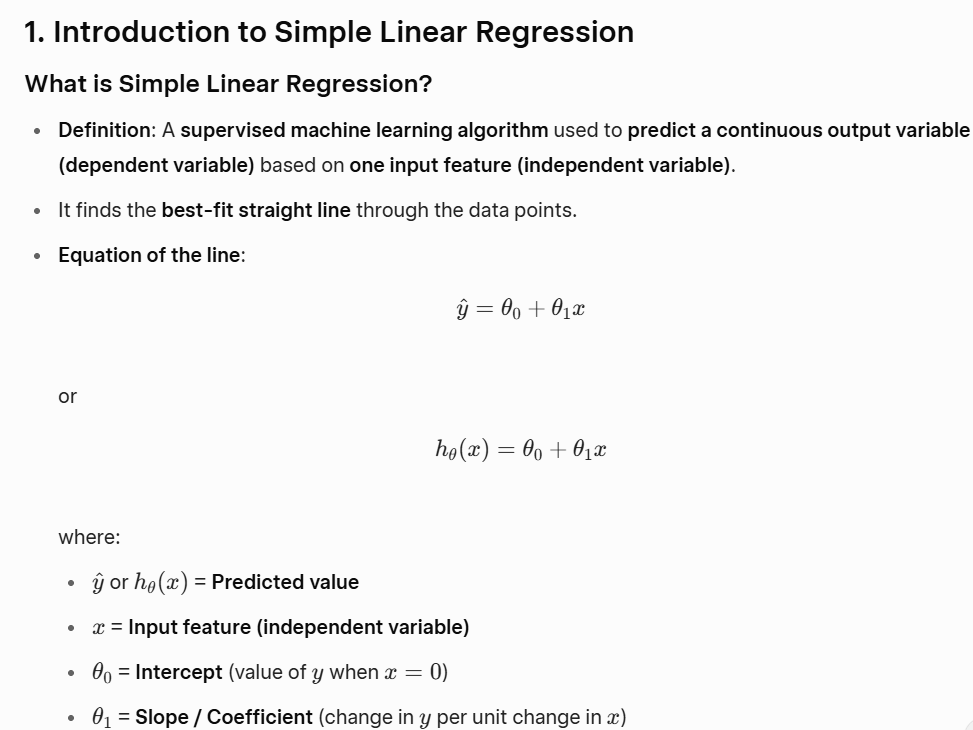

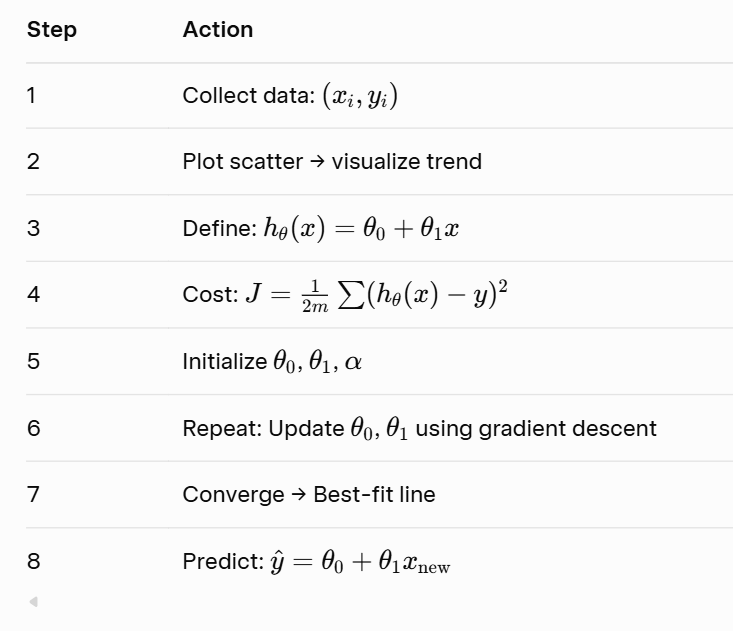

Data Science Life Cycle
- Data Collection(Database,API,Scraping,etc.)
- Data Loading
- Data Cleaning, EDA, Feature Engineering
- Independent and Dependent Feature
- X_train, X_test, y_train, y_test
- Model Train
- Performance Check
- Hyperparamter Tuning
- Save and Deploy Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline is a magic command in Jupyter Notebook (or Google Colab) that tells Python to display plots directly inside the notebook instead of opening them in a separate window.

In [2]:
# Read the dataset
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [3]:
df.shape

(300, 2)

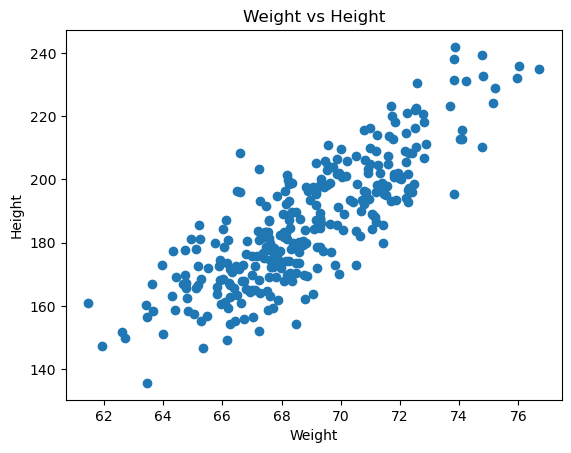

In [4]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')
plt.show()

In [5]:
## Divide the dataset into independent and dependent variables
X = df[['Weight']] # Independent feature
y = df[['Height']] # Dependent feature

In [6]:
X, y

(        Weight
 0    73.847017
 1    68.781904
 2    74.110105
 3    71.730978
 4    69.881796
 ..         ...
 295  67.852131
 296  67.549069
 297  74.767447
 298  71.418946
 299  67.120344
 
 [300 rows x 1 columns],
          Height
 0    241.893563
 1    162.310473
 2    212.740856
 3    220.042470
 4    206.349801
 ..          ...
 295  194.744522
 296  183.266533
 297  210.369909
 298  198.042484
 299  172.664090
 
 [300 rows x 1 columns])

In [7]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [8]:
X_train

,Weight
232,76.021347
59,70.013365
6,68.785081
185,68.287042
173,71.981207
...,...
188,65.755499
71,70.523225
106,67.556051
270,72.049890


In [9]:
X.shape

(300, 1)

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((240, 1), (60, 1), (240, 1), (60, 1))

In [11]:
## Standardize the dataset over independent train data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [12]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

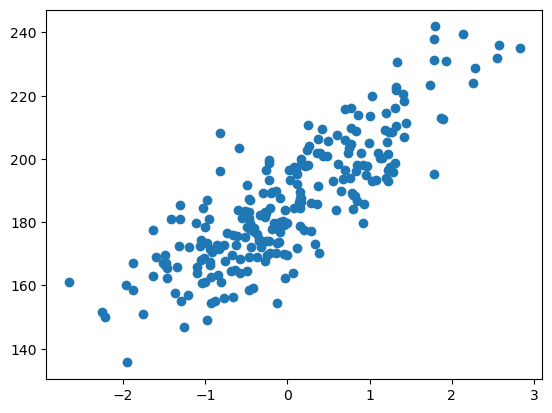

In [13]:
plt.scatter(X_train, y_train)
plt.show()

In [14]:
# Train the model Simple Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
print("The slope or coefficient of weight is: ", model.coef_)
print("The intercept of the line is: ", model.intercept_)

The slope or coefficient of weight is:  [[16.75884807]]
The intercept of the line is:  [186.32650958]


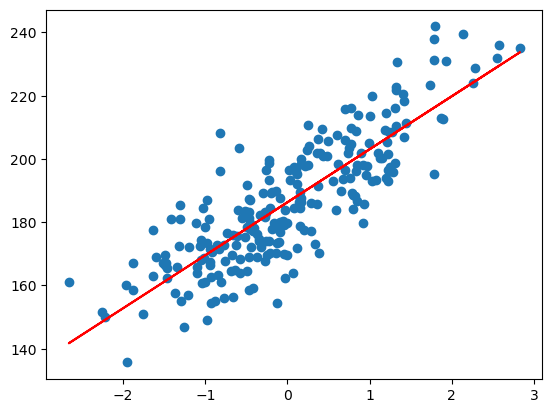

In [17]:
# Plotting the training data points (actual data)
plt.scatter(X_train, y_train)  
# This draws a scatter plot of the training data (X vs y)
# Each point represents an actual observation from the training set

# Plotting the regression line (predicted values)
plt.plot(X_train, model.predict(X_train), 'r')  
# This draws a red ('r') line showing the model's predicted values
# It visually represents the "best fit line" that the regression model has learned

# Display the plot
plt.show()  
# This shows both the scatter points and the red regression line together
# Helps you see how well the line fits the actual data


# In Simple Terms

# Blue dots (scatter plot): your real training data.

# Red line: the line your model learned to predict outcomes.

# You use this to check how well the model fits — if the red line goes smoothly through the middle of the blue points,
# your regression model is performing well.

In [19]:
y_pred_test = model.predict(X_test)

In [20]:
y_pred_test, y_test

(array([[159.46080926],
        [183.21758961],
        [198.29286069],
        [153.6954315 ],
        [202.10836624],
        [162.14278668],
        [176.61622009],
        [178.76400106],
        [176.61435393],
        [173.01126809],
        [180.80725433],
        [197.87267771],
        [203.91180583],
        [193.82998272],
        [171.47843166],
        [173.80066135],
        [164.18672117],
        [195.15788529],
        [170.27165928],
        [163.72869041],
        [172.14476386],
        [188.3489793 ],
        [202.89594758],
        [179.46212498],
        [193.6555303 ],
        [164.64532882],
        [186.12596489],
        [180.23110408],
        [144.52446968],
        [217.97589447],
        [156.8214891 ],
        [176.67827877],
        [188.24818605],
        [180.47901001],
        [222.14622804],
        [203.49479053],
        [183.22769041],
        [204.15677535],
        [182.64405615],
        [178.6804748 ],
        [161.39498404],
        [204.119

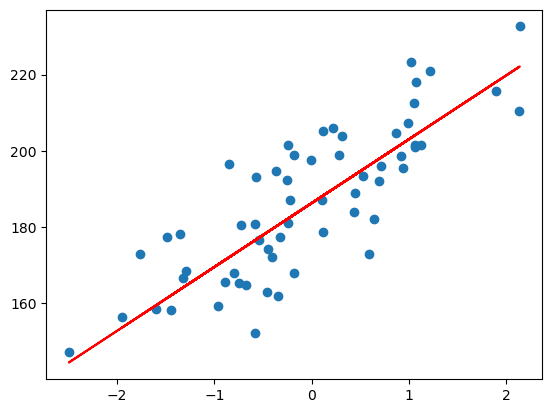

In [21]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model.predict(X_test), 'r')
plt.show()

Performance Metrics

 MSE, RMSE, MAE
 
  R2 Score, Adjusted R2 Score

#Mean Squared Error (MSE)

Meaning: It measures how far the predicted values are from the actual values.

Formula: Average of squared differences between predicted and actual values.

Example: If predictions are very wrong, squaring makes the error large — so MSE heavily penalizes big mistakes.

Lower MSE = Better model.

#Root Mean Squared Error (RMSE)

Meaning: It’s just the square root of MSE.

Why: It brings the error back to the original unit of the data (so easier to interpret).

Lower RMSE = Better performance.

Mean Absolute Error (MAE)

Meaning: It measures the average of absolute differences between predicted and actual values.

Example: Unlike MSE, it doesn’t square errors — so it’s less affected by big outliers.

Lower MAE = Better accuracy.

R² Score (Coefficient of Determination)

Meaning: Tells how well your model explains the variance in the data.

Range: 0 to 1

1 = Perfect prediction

0 = Model predicts nothing better than mean

Example: If R² = 0.8 → model explains 80% of the variation in target.

Adjusted R² Score

Meaning: A modified version of R² that adjusts for the number of predictors in the model.

Why: Adding more variables always increases R², even if they’re useless — Adjusted R² fixes that.

Rule: Use Adjusted R² when comparing models with different numbers of features.

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [23]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print("Mean Squared Error: ", mse)
print("Mean Absolute Error: ", mae)
print("Root Mean Squared Error: ", rmse)

Mean Squared Error:  127.32672937047964
Mean Absolute Error:  9.269094509971893
Root Mean Squared Error:  11.283914629705404


| Metric                             | Your Value | Meaning in Simple Words                                                                                                                                                                                         |
| :--------------------------------- | :--------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Mean Squared Error (MSE)**       | 127.33     | This shows the **average squared difference** between the predicted and actual values. Larger errors are penalized more. Smaller MSE → better accuracy.                                                         |
| **Mean Absolute Error (MAE)**      | 9.27       | This is the **average distance** between the predicted and actual values (in the same units as your target). On average, your model’s predictions are off by about **9.27 units**.                              |
| **Root Mean Squared Error (RMSE)** | 11.28      | This is just the **square root of MSE**. It’s also in the same units as your target, so easier to interpret. It means your model’s predictions differ from the real values by about **11.28 units** on average. |


Summary

MAE → tells average error (how far off, in general).

MSE → punishes large mistakes more heavily.

RMSE → similar to MAE but more sensitive to big errors.

In [24]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)
print(score)
print("R2 Score: ", score * 100, '%')

0.661844826421359
R2 Score:  66.1844826421359 %


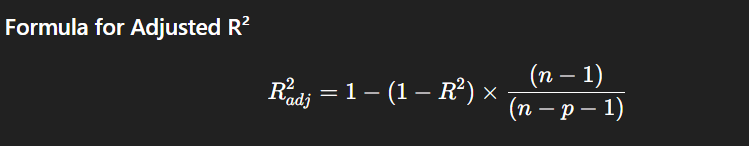

Where:

R² → coefficient of determination (model’s goodness of fit)

n → number of data points (samples in your test set)

p → number of predictors (features used in the model)

In [25]:
# Display Adjusted R2 Score
adjusted_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print("Adjusted R2 Score: ", adjusted_r2 * 100, '%')

Adjusted R2 Score:  65.6014564807934 %


This means your model explains around 65.6% of the variation in the target variable after adjusting for the number of features.

In simple terms:

Your model is doing a decent job — it captures about two-thirds of the true patterns in the data,
while the remaining 34.4% is due to random noise or missing factors not included in your model.

Meaning

R² tells how much of the target variable’s variation is explained by the model.
→ Example: R² = 0.70 → 70% of variation is explained.

But R² can be misleading, because it always increases when you add more features — even useless ones.

Adjusted R² fixes that by penalizing irrelevant features.
It only increases if a new feature actually improves the model.

In [26]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
## New data point weight is 80

scaled_weight = scaler.transform([[50]])
scaled_weight

array([[-6.79435273]])

In [28]:
print('The height of the person with weight 50 is: ', model.predict(scaled_weight))

The height of the person with weight 50 is:  [[72.46098448]]


Assumptions of Linear Regressionss

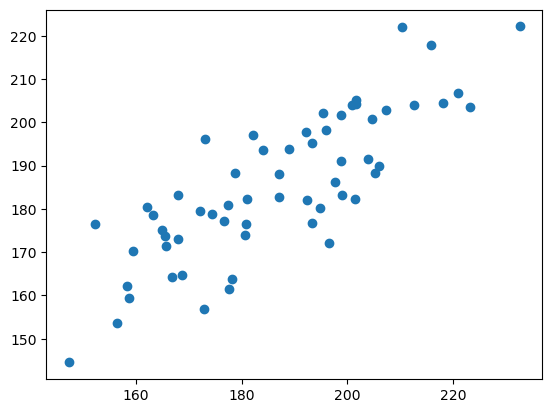

In [29]:
## Plot a scatter plot for the prediction
plt.scatter(y_test, y_pred_test)
plt.show()

Residuals

A residual is the difference between the actual value and the predicted value from a regression model.

Formula:



Residual=Actual Value−Predicted Value

Positive residual → model predicted less than actual.

Negative residual → model predicted more than actual.

In short:

Residuals tell you how far off your model is for each data point.

Small residuals → model fits well.

Large residuals → model may be underfitting or overfitting.

In [30]:
# Residuals
residuals = y_test - y_pred_test
print(residuals)

        Height
203  -0.881412
266  15.703390
152  -2.355846
9     2.704245
233  -6.715749
226  -3.801344
196   4.163560
109  -4.399819
5   -24.402198
175  -4.997238
237  -3.459475
57   -5.747830
218   8.714296
45   -4.907680
182  -5.909933
221  -8.369419
289   2.520652
211  -1.811325
148 -10.881336
165  14.406255
78   24.305096
113  -9.663433
249   4.354529
250  -7.309353
104  -9.716673
42    3.972417
281  11.611940
295  14.513418
157   2.739217
238  -2.216191
17   16.061981
164  16.539394
33   16.935435
24  -18.472358
215  10.489175
119  19.804545
7   -15.256580
90   -2.536109
46    4.416496
73  -15.572473
93   16.154279
76   -3.198573
286 -23.244517
60   -2.908374
77   14.150701
63  -10.124822
234  -0.683249
229  13.801392
111  19.213073
231  -3.551539
180  -1.158708
144  15.973342
239  -1.151363
75    3.894037
297 -11.607722
278   7.756536
97    6.605828
92  -14.941686
192  12.335404
25   10.350712


Interpretation:

If residual = 0 → perfect prediction 

If residual > 0 → model underestimated (predicted less than actual)

If residual < 0 → model overestimated (predicted more than actual)

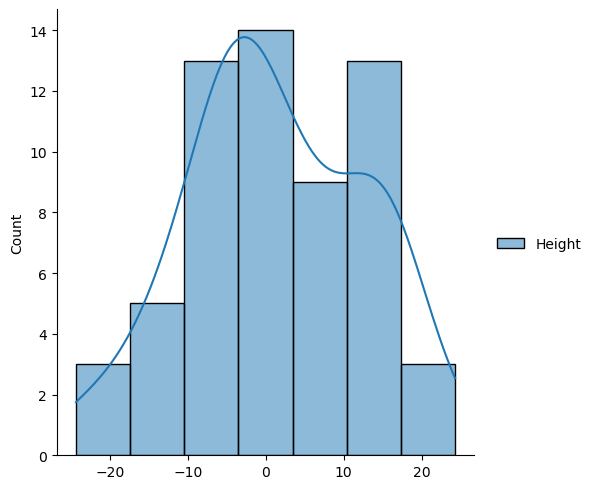

In [31]:
import seaborn as sns
# Plot the residuals
sns.displot(residuals, kde = True)
plt.show()

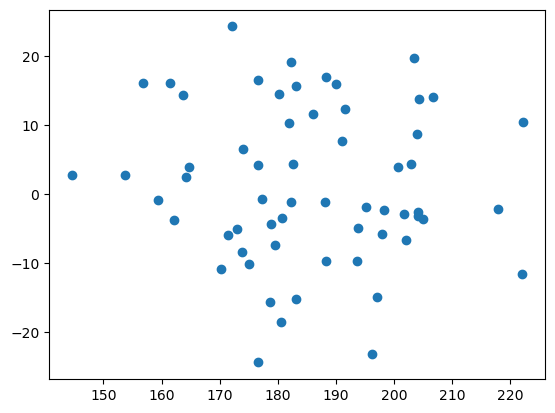

In [32]:
## Scatter plot with respect to prediction and residuals
# uniform distribution
plt.scatter(y_pred_test, residuals)
plt.show()

In [33]:
x_train_pred = model.predict(X_train)

Overfitting → Too complex → Great on training, bad on testing.

Underfitting → Too simple → Bad on both.

Overfitting

When a model learns too much from the training data, including noise and details — it performs well on training data but poorly on new/unseen data.
Example: Like memorizing answers instead of understanding the concept.

Underfitting

When a model is too simple and cannot capture the actual pattern in data — it performs poorly on both training and test data.
Example: Like studying too little and failing to understand even the basics.